In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pylab as pl
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
# reading data
df = pd.read_csv("./FuelConsumption.csv")

df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [5]:
df["TRANSMISSION"].head()

0    AS5
1     M6
2    AV7
3    AS6
4    AS6
Name: TRANSMISSION, dtype: object

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   MAKE                      1067 non-null   object 
 2   MODEL                     1067 non-null   object 
 3   VEHICLECLASS              1067 non-null   object 
 4   ENGINESIZE                1067 non-null   float64
 5   CYLINDERS                 1067 non-null   int64  
 6   TRANSMISSION              1067 non-null   object 
 7   FUELTYPE                  1067 non-null   object 
 8   FUELCONSUMPTION_CITY      1067 non-null   float64
 9   FUELCONSUMPTION_HWY       1067 non-null   float64
 10  FUELCONSUMPTION_COMB      1067 non-null   float64
 11  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 12  CO2EMISSIONS              1067 non-null   int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 108.5+ KB


In [4]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [10]:
cdf = df[["ENGINESIZE", "CYLINDERS", "FUELCONSUMPTION_COMB", "CO2EMISSIONS"]]

cdf.head()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244


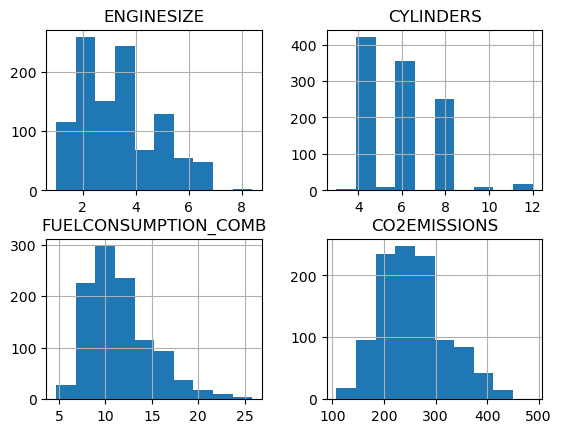

In [15]:
viz = cdf[["ENGINESIZE", "CYLINDERS", "FUELCONSUMPTION_COMB", "CO2EMISSIONS"]]
viz.hist()
plt.show()

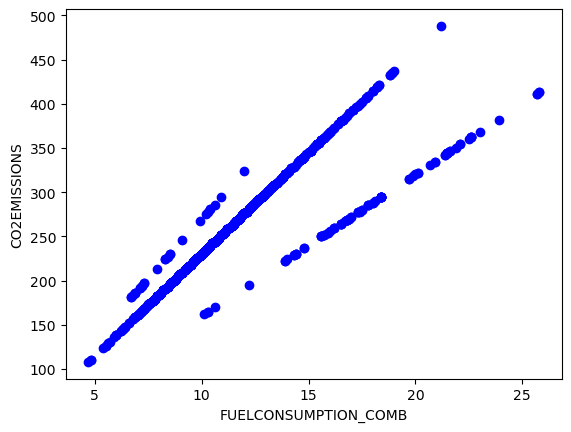

In [16]:
plt.scatter(cdf["FUELCONSUMPTION_COMB"], cdf["CO2EMISSIONS"], color="blue")
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("CO2EMISSIONS")
plt.show()

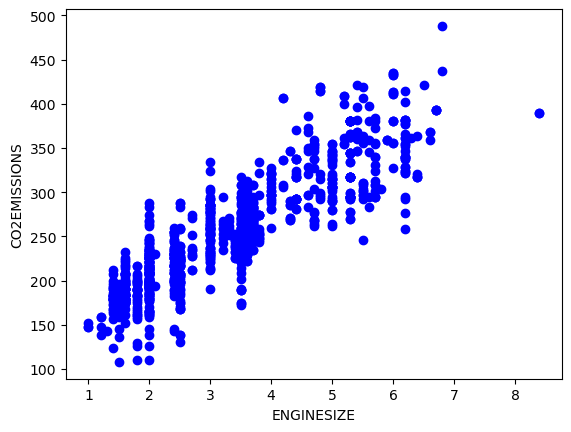

In [17]:
plt.scatter(cdf["ENGINESIZE"], cdf["CO2EMISSIONS"], color="blue")
plt.xlabel("ENGINESIZE")
plt.ylabel("CO2EMISSIONS")
plt.show()

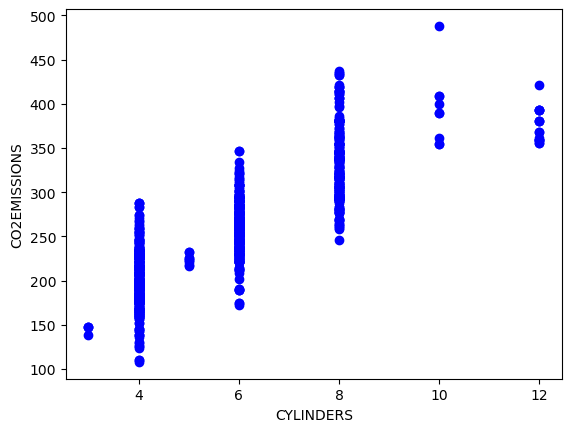

In [18]:
plt.scatter(cdf["CYLINDERS"], cdf["CO2EMISSIONS"], color="blue")
plt.xlabel("CYLINDERS")
plt.ylabel("CO2EMISSIONS")
plt.show()

In [21]:
np.random.rand()

0.5338177608500446

In [22]:
# spliting data into train and test sets using numpy

msk = np.random.rand(len(cdf)) < 0.8
train = cdf[msk]
test = cdf[~msk]

print(msk)
print(~msk)

print(f'train size: {len(train)}')
print(f'test size: {len(test)}')

[ True  True  True ...  True False  True]
[False False False ... False  True False]
train size: 864
test size: 203


Text(0, 0.5, 'CO2EMISSIONS')

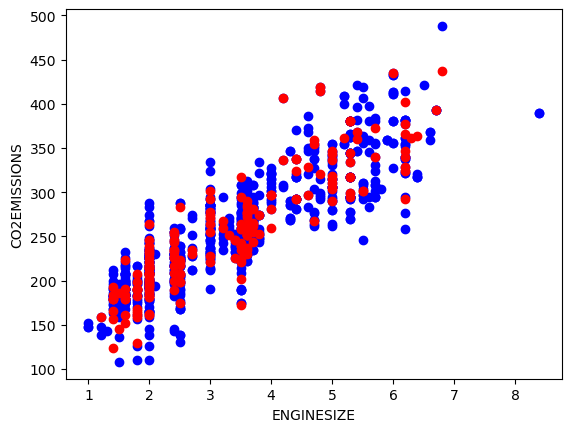

In [33]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color="blue")
ax.set_xlabel("ENGINESIZE")
ax.set_ylabel("CO2EMISSIONS")

ax.scatter(test.ENGINESIZE, test.CO2EMISSIONS, color="red")
ax.set_xlabel("ENGINESIZE")
ax.set_ylabel("CO2EMISSIONS")

In [35]:
model = LinearRegression()
train_x = np.asanyarray(train[["ENGINESIZE"]])
train_y = np.asanyarray(train[["CO2EMISSIONS"]])
model.fit(train_x, train_y)

coef = model.coef_
intercept = model.intercept_

print(f"Coefficient: {coef} Intercept: {intercept}")

Coefficient: [[38.57720036]] Intercept: [127.09739265]


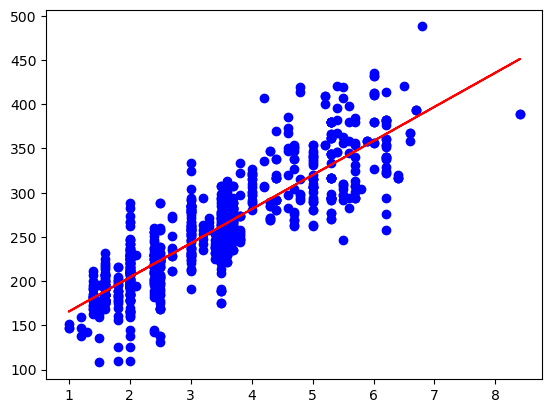

In [36]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color="blue")
plt.plot(train_x, model.coef_[0][0] * train_x + model.intercept_[0], "-r")

In [43]:
test_x = np.asanyarray(test[["ENGINESIZE"]])
test_y = np.asanyarray(test[["CO2EMISSIONS"]])
predict_result = model.predict(test_x)

mae = np.mean(np.absolute(predict_result - test_y))
mse = np.mean(np.square(predict_result - test_y))
r2 = r2_score(test_y, predict_result)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R2 score: {r2}")

MAE: 22.21651645009287
MSE: 888.3663152236729
R2 score: 0.7930873371169752


In [45]:
random_enginesize = 8
predicted_emission = model.predict([[random_enginesize]])
print(f"For a Machine with engine size {random_enginesize}, the predicted CO2 emission is {predicted_emission[0][0]}")

For a Machine with engine size 8, the predicted CO2 emission is 435.7149955011102
